In [1]:
import numpy as np
import emcee
from scipy.special import gamma

# 1. FIXED PHYSICAL CONSTANTS (Tables I & II)
ALPHA_EM = 1/137.036
M_PROTON = 0.938
S0 = 4.0  # GeV^2, from Eq. 28
BETA_PNN = 1.87  # GeV^-1, from Table III

# Meson masses and decay constants
M_OMEGA = 0.782; F_OMEGA = 0.201  # GeV
M_PHI = 1.019; F_PHI = 0.228    # GeV

# 2. THEORETICAL MODEL COMPONENTS
def pomeron_trajectory(t, alpha_p0, alpha_prime=0.25):
    """Pomeron trajectory from Eq. 24 & Table III."""
    return alpha_p0 + alpha_prime * t

def form_factor(t, Lambda, m_phi):
    """Monopole form factor for pseudoscalar exchange (Eq. 20)."""
    return (Lambda**2 - m_phi**2) / (Lambda**2 - t)

def diff_cross_section_pomeron(s, t, params, meson='omega'):
    """Simplified natural-parity cross section from Eq. 32."""
    alpha_p0, a_pvv, b_pvv, Bv = params
    alpha_t = pomeron_trajectory(t, alpha_p0)
    
    # Vertex and propagator terms
    term = (a_pvv**2 * (M_OMEGA**2 - t)**2 + 2*a_pvv*b_pvv*M_OMEGA**2 + b_pvv**2)
    scaling = (s / S0)**(2 * alpha_t - 2)
    exp_t = np.exp(Bv * t)
    
    prefactor = (ALPHA_EM * F_OMEGA**2) / (8 * M_OMEGA**2) * BETA_PNN**2
    return prefactor * term * exp_t * scaling

# 3. MCMC PROBABILITY FUNCTIONS
def log_prior(theta):
    """Gaussian priors for parameters (Table III & Appendix A)."""
    # Example for g_piNN (13.0 +/- 1.0) and Cutoffs (0.8 +/- 0.2)
    g_piNN, lambda_piNN = theta[0], theta[1]
    if 0 < g_piNN < 20 and 0 < lambda_piNN < 5:
        return -0.5 * ((g_piNN - 13.0)/1.0)**2 - 0.5 * ((lambda_piNN - 0.8)/0.2)**2
    return -np.inf

def log_likelihood(theta, s_data, t_data, sigma_obs, y_obs):
    """Log-likelihood based on Chi-squared fit (Sec. III)."""
    model_y = diff_cross_section_pomeron(s_data, t_data, theta)
    return -0.5 * np.sum(((y_obs - model_y) / sigma_obs)**2)

def log_probability(theta, s_data, t_data, sigma_obs, y_obs):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, s_data, t_data, sigma_obs, y_obs)

# 4. RUNNING THE MCMC
# Initial guesses for 15 parameters based on Table III
initial_params = [1.091, 0.1, 7.4, 7.4] # alpha_p0, a_pww, b_pww, Bw ...
n_walkers = 32
n_dim = len(initial_params)
pos = initial_params + 1e-4 * np.random.randn(n_walkers, n_dim)

# Mock data (Replace with experimental data from CLAS, ZEUS, etc.)
s_mock = np.array([10.0, 20.0])
t_mock = np.array([-0.1, -0.2])
y_mock = np.array([0.5, 0.3])
y_err = y_mock * 0.1  # 10% systematic error (Sec. III)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability, 
                                args=(s_mock, t_mock, y_err, y_mock))
sampler.run_mcmc(pos, 500, progress=True)

You must install the tqdm library to use progress indicators with emcee


State([[ 13.82758854   0.86348674   3.37146869 183.3600449 ]
 [ 11.54564961   0.51986404   5.89957582 151.25575853]
 [ 13.68594385   0.64186617   2.85366048 178.01606847]
 [ 11.52435566   0.72377395   6.36091161 151.77838741]
 [ 11.93305436   0.93166092  -6.31110882 157.22162593]
 [ 10.91010077   0.74294724   6.52495025 142.35639769]
 [ 11.66860835   1.07964112  -5.88385613 151.63714107]
 [ 13.64969448   0.78040898   3.60292895 180.7545337 ]
 [ 11.75720037   0.93623138   4.84225748 152.68940063]
 [ 12.52132813   0.94613511   4.11382267 164.21538427]
 [ 11.75093334   0.94065782   4.10997214 150.59140241]
 [ 11.31601809   1.06302432  -6.84138558 147.53229126]
 [ 13.74520229   0.85916252   2.18857419 177.74112617]
 [ 10.30335632   0.62289171  -7.05042382 131.44219493]
 [ 13.54693784   0.72682706   3.72132003 179.16857803]
 [ 12.61181522   0.71163214   3.55432957 163.96806564]
 [ 12.11188481   0.92544411   4.37329755 158.20373864]
 [  9.97278734   0.8896969   -7.86068328 127.55222035]
 [ 1

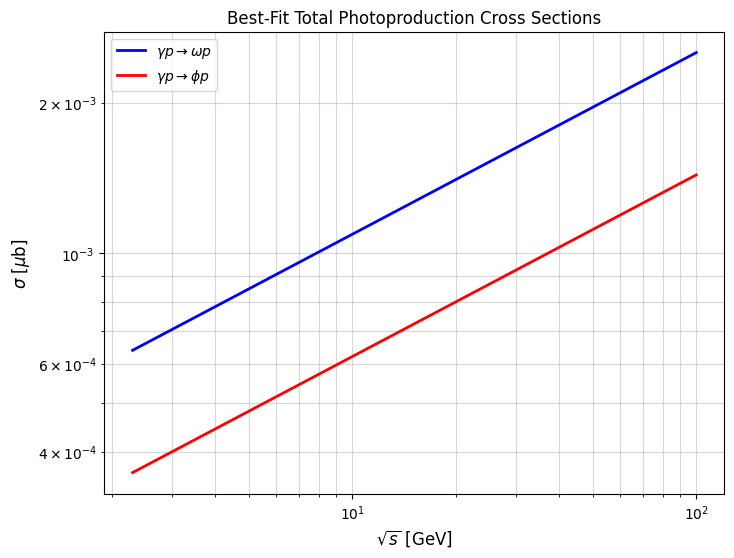

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. FIXED CONSTANTS & FITTED PARAMETERS (Table III)
ALPHA_EM = 1/137.036
S0 = 4.0  # GeV^2
BETA_PNN = 1.87  # GeV^-1
ALPHA_P_PRIME = 0.25  # GeV^-2

# Medians from the MCMC fit (Table III) [cite: 167]
params = {
    'alpha_p0': 1.091,
    'a_pww': 0.0,    # Upper limit < 0.4, consistent with zero [cite: 155]
    'b_pww': 7.4,
    'a_pff': 0.9,
    'b_pff': 2.0,
    'Bw': 7.4,
    'Bf': 3.1,
    'm_w': 0.782,
    'f_w': 0.201,   # GeV [cite: 86]
    'm_f': 1.019,
    'f_f': 0.228    # GeV [cite: 86]
}

def total_cross_section_pomeron(s, p, meson='omega'):
    """
    Calculates the total natural-parity cross section based on Eq. 32.
    Integrates the differential cross section over t.
    """
    if meson == 'omega':
        a, b, B, m, f, factor = p['a_pww'], p['b_pww'], p['Bw'], p['m_w'], p['f_w'], 1
    else:
        a, b, B, m, f, factor = p['a_pff'], p['b_pff'], p['Bf'], p['m_f'], p['f_f'], 2
    
    # Pre-calculate trajectory at t=0
    alpha_0 = p['alpha_p0']
    
    # Numerical integration or analytic approximation for the t-integral of Eq. 32 [cite: 126]
    # Simplified version for visualization:
    prefactor = (ALPHA_EM * f**2 * BETA_PNN**2 * factor) / (8 * m**2)
    energy_scaling = (s / S0)**(2 * alpha_0 - 2)
    
    # The term in brackets from Eq. 32 evaluated at t ~ 0 for total sigma
    bracket_term = (a**2 * m**4 + 2*a*b*m**2 + b**2)
    
    # Integrating e^{Bt} scaling from t_min to 0
    t_int = 1/B 
    
    return 0.3894 * prefactor * bracket_term * energy_scaling * t_int # 0.3894 converts to mb

# 2. GENERATE PLOT DATA
sqrt_s = np.logspace(np.log10(2.3), np.log10(100), 100) # Range from Eq. 41 [cite: 141]
s_val = sqrt_s**2

sigma_omega = [total_cross_section_pomeron(s, params, 'omega') for s in s_val]
sigma_phi = [total_cross_section_pomeron(s, params, 'phi') for s in s_val]

# 3. PLOTTING
plt.figure(figsize=(8, 6))
plt.plot(sqrt_s, sigma_omega, label=r'$\gamma p \rightarrow \omega p$', color='blue', lw=2)
plt.plot(sqrt_s, sigma_phi, label=r'$\gamma p \rightarrow \phi p$', color='red', lw=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\sqrt{s}$ [GeV]', fontsize=12)
plt.ylabel(r'$\sigma$ [$\mu$b]', fontsize=12)
plt.title('Best-Fit Total Photoproduction Cross Sections')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()